# Pipeline walkthrough

This notebook is the narrative companion to the Figure 1 decision tree. The tree shows the classification boundaries; this walkthrough shows what the code actually reads, what selections it makes, and how each figure-producing section of `grb_main.ipynb` turns a classified population into a result. It guides a reader from the raw COMPAS HDF5 catalogue (Broekgaarden et al. 2021, arXiv:2103.02608) through to the GRB and kilonova class fractions and the publication figures. Every step points at a concrete symbol in `src/grb_*.py` and, where relevant, at the saved figure.

The classification frameworks are Gottlieb et al. (2023, arXiv:2309.00038), which unifies short and long GRBs from compact binary mergers, and Gottlieb et al. (2025, arXiv:2411.13657), which fixes the engine-plus-ejecta hybrid taxonomy used here. The population synthesis is the COMPAS grid of Broekgaarden et al. (2021, arXiv:2103.02608) and its paper-II companion (Broekgaarden et al. 2022, arXiv:2112.05763).

The code cells in Part A run live on Model A (load, remap, classify, cross-check, mass-plane preview); they execute in seconds. Part B is a tour of the heavier sections (rates, offsets, the 20-model grid) and embeds the already-saved figures from `plots/` rather than recomputing them. Full bibliographic entries with arXiv identifiers are collected in the References section at the end.

For the classification boundaries themselves see [README.md](README.md); for the physical constants and their citations see the per-constant docstrings in [src/grb_physics.py](src/grb_physics.py).

In [1]:
import sys

sys.path.insert(0, "src")

import numpy as np
import matplotlib.pyplot as plt

from grb_io import load_bns, load_bhns
from grb_physics import (
    remap_ns_masses_double_gaussian,
    remap_ns_marginal,
    M_TOV,
    M_THRESH,
    Q_THRESH_BNS,
    MDISK_SHORT,
    MDISK_LONG,
)
from grb_classify import classify_bns_2024, classify_bhns, classify_grid
from grb_plot_style import apply_apj_rcparams

apply_apj_rcparams()

print(f"M_TOV={M_TOV} Msun, M_THRESH={M_THRESH:.3f} Msun, "
      f"q_thresh={Q_THRESH_BNS}, MDISK_SHORT/LONG={MDISK_SHORT}/{MDISK_LONG} Msun")

M_TOV=2.2 Msun, M_THRESH=2.794 Msun, q_thresh=1.2, MDISK_SHORT/LONG=0.01/0.1 Msun


## Part A. The core pipeline (COMPAS to classes)

Every section in the notebook, regardless of what it plots, starts from the same three-stage core: load and select, remap the neutron-star masses, classify. The sections differ only in what they do with the classified population afterwards.

```mermaid
flowchart TD
    h5["COMPAS HDF5 (doubleCompactObjects group)"] --> sel["Stage 0 selections: mergesInHubbleTimeFlag==1; carry STROOPWAFEL weight; BH vs NS by stellarType1==14; sort m1 >= m2"]
    sel --> remap["Stage 1: NS-mass remap to Alsing+ 2018 (remap_ns_masses_double_gaussian / remap_ns_marginal)"]
    remap --> bnsBranch["BNS discriminants: M_tot, q"]
    remap --> bhnsBranch["BHNS discriminant: M_disk = M_rem(Foucart 2018) - M_dyn(Kruger and Foucart 2020)"]
    bnsBranch --> bnsCls["classify_bns_2024: 4 classes"]
    bhnsBranch --> bhnsCls["classify_bhns: 3 classes"]
    bnsCls --> grid["classify_grid: unified mass-plane labels 0-6"]
    bhnsCls --> grid
```

### Stage 0. Ingestion and selections

All ingestion lives in [src/grb_io.py](src/grb_io.py). The loaders read the COMPAS `doubleCompactObjects` group of the Broekgaarden et al. (2021, arXiv:2103.02608) catalogues and return plain numpy arrays. Pick the most specific loader for the task; only the `*_with_kicks` loaders parse the `supernovae` group, so the others are faster.

| Loader | Adds beyond the baseline keys | Used by |
|---|---|---|
| `load_bns` / `load_bhns` | baseline only | Sections 1, 2, 3, 5 |
| `load_bns_with_channels` / `load_bhns_with_channels` | `dblCE`, `fc_CEE`, `fc_mt_p1`, `fc_mt_s1`, `fc_mt_p1_K1`, `fc_mt_s1_K2`, ZAMS masses, separations | channel splits (3b, 5b, 6b, 7b), Section 11.5 crosstab |
| `load_bns_with_kicks` / `load_bhns_with_kicks` | `v_sys` (via `_match_sn_to_dco`), `drawnKick1/2`, `sep_DCO`, `ecc_DCO` | Section 8 offsets |

Baseline keys returned by every loader: `m1`, `m2` (or `M_BH`, `M_NS`), `weights`, `metallicity`, `delay_time`, `n_merging`, `mask_merging`, `model`, `ns_max`.

Four selections and conventions are applied here, and they propagate to every downstream result:

1. Merger cut. Only systems with `mergesInHubbleTimeFlag == 1` are kept (`mask = mh == 1` in `load_bns`). The cut is applied before anything else, so non-merging systems never enter a figure.
2. STROOPWAFEL weights are mandatory. The COMPAS sample is adaptive-importance-sampled with STROOPWAFEL (Broekgaarden et al. 2019, arXiv:1905.00910), which oversamples the rare regions of birth-parameter space that produce merging double compact objects. Every reduction is therefore weighted: counts use `w[mask].sum()`, means use `np.average(x, weights=w)`, histograms pass `weights=w`. Raw counts are biased and are never used for science output. `_check_weights_no_nan` hard-fails if a weight is NaN after the merging mask.
3. BH versus NS identity (BHNS only) is by stellar type, not by mass: `stellarType1 == 14` marks the black hole (`M_BH = np.where(is_BH1, m1, m2)`). This is why `M_BH` and `M_NS` come back already split by type rather than by mass order.
4. Mass ordering (BNS). With `sort_masses=True` (the default) the loader enforces `m1 >= m2`, so the mass ratio `q = m1 / m2 >= 1` is well defined. Note that `load_bns_with_channels` swaps the compact-object masses but does not reorder the per-component formation-channel arrays; those still reference the original COMPAS primary/secondary labelling.

Each loader also reads the embedded `model` and `ns_max` root attributes written by [tools/embed_model_metadata.py](tools/embed_model_metadata.py) and validates them against the caller's `expected_model` / `expected_ns_max`. Passing `bns['ns_max']` straight into `classify_grid` means the NS-mass cap can never drift from the run configuration.

The cell below loads Model A, prints the embedded metadata, and contrasts a raw fraction against the STROOPWAFEL-weighted fraction to show why the weights are not optional.

In [2]:
bns = load_bns(expected_model="A", expected_ns_max=2.5)
w = bns["weights"]
print(f"merging BNS systems (Model A): {bns['n_merging']:,}")
print(f"embedded metadata: model={bns['model']!r}, ns_max={bns['ns_max']}")

# Why weights matter: weighted vs raw fraction of one class (pre-remap masses,
# for illustration only; the science classification runs after the Stage 1 remap).
cls_raw = classify_bns_2024(bns["m1"], bns["m2"])
m = cls_raw["sbGRB + blue KN"]
print(f"\nsbGRB + blue KN  raw (unweighted) fraction   = {m.mean():.3f}")
print(f"sbGRB + blue KN  STROOPWAFEL-weighted fraction = {w[m].sum() / w.sum():.3f}")

# BH vs NS identity is by stellarType1 == 14, so the loader returns them pre-split.
bhns = load_bhns(expected_model="A", expected_ns_max=2.5)
print(f"\nBHNS (Model A): median M_BH = {np.median(bhns['M_BH']):.2f} Msun, "
      f"median M_NS = {np.median(bhns['M_NS']):.2f} Msun")

merging BNS systems (Model A): 233,137
embedded metadata: model='A', ns_max=2.5

sbGRB + blue KN  raw (unweighted) fraction   = 0.553
sbGRB + blue KN  STROOPWAFEL-weighted fraction = 0.458

BHNS (Model A): median M_BH = 11.41 Msun, median M_NS = 1.86 Msun


**Source.** Merger cut `mask = mh == 1` at [grb_io.py L233](src/grb_io.py#L233); NaN-weight guard `_check_weights_no_nan` at [L238](src/grb_io.py#L238) (def [L103](src/grb_io.py#L103)). The COMPAS sample is STROOPWAFEL importance-sampled (Broekgaarden et al. 2019, arXiv:1905.00910), so the raw and weighted fractions differ and only the weighted fraction is science.

### Stage 1. The neutron-star mass remap

This step is not visible in the Figure 1 tree but it materially moves the BNS class fractions, so it belongs on any methods slide. The Broekgaarden et al. (2021, arXiv:2103.02608) catalogues use the Fryer et al. (2012, arXiv:1110.1726) delayed supernova engine, which leaves a known neutron-star gravitational-mass deficit near 1.7 Msun (Broekgaarden et al. 2021 footnote 3). Immediately after loading, `grb_main.ipynb` overwrites the NS masses with a weighted, rank-preserving quantile remap onto the Alsing, Silva and Berti (2018, arXiv:1709.07889) Galactic double-Gaussian NS mass distribution, following the remnant-mass recipe of Mandel and Muller (2020, arXiv:2006.08360):

- BNS: `remap_ns_masses_double_gaussian(m1, m2, weights=...)` in [src/grb_physics.py](src/grb_physics.py), per-component marginal remap.
- BHNS: `remap_ns_marginal(M_NS, weights=...)` on the NS column only.

The target is the two-Gaussian fit (peaks near 1.34 and 1.80 Msun) truncated to `[NS_REMAP_M_MIN, M_TOV] = [1.10, 2.2]`. RNG seeds are fixed (42 for BNS, 43 for BHNS in Section 0; `42 + i` and `43 + i` per model in the Section 11 grid scan).

Consequence to state plainly: every classifier and every rate downstream sees the remapped masses. Reloading raw masses in a later cell without reapplying the remap is a bug.

The cell below applies the BNS remap and overlays the weighted NS-mass distribution before and after.

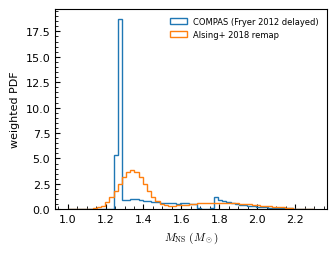

In [3]:
m1_raw, m2_raw = bns["m1"].copy(), bns["m2"].copy()
m1, m2 = remap_ns_masses_double_gaussian(
    m1_raw, m2_raw, weights=w, rng=np.random.default_rng(42)
)

fig, ax = plt.subplots(figsize=(3.5, 2.6))
bins = np.linspace(1.0, 2.3, 60)
w2 = np.concatenate([w, w])
ax.hist(np.concatenate([m1_raw, m2_raw]), bins=bins, weights=w2,
        histtype="step", density=True, label="COMPAS (Fryer 2012 delayed)")
ax.hist(np.concatenate([m1, m2]), bins=bins, weights=w2,
        histtype="step", density=True, label="Alsing+ 2018 remap")
ax.set_xlabel(r"$M_{\rm NS}\ (M_\odot)$")
ax.set_ylabel("weighted PDF")
ax.legend(fontsize=6, frameon=False)
plt.show()

**Source.** `remap_ns_masses_double_gaussian` at [grb_physics.py L371](src/grb_physics.py#L371) (BHNS marginal variant `remap_ns_marginal` at [L317](src/grb_physics.py#L317)). The plot shows the Fryer (2012) delayed-engine NS-mass deficit near 1.7 $M_\odot$ closed onto the Alsing+ 2018 Galactic double-Gaussian (Mandel and Muller 2020, arXiv:2006.08360). Every downstream classifier and rate sees these remapped masses, not the raw COMPAS ones.

### Stage 2. Classification

The classifiers live in [src/grb_classify.py](src/grb_classify.py). BNS and BHNS use different discriminants.

BNS, four classes, decided purely on total mass and mass ratio (no disk-mass model enters the BNS path):

```python
"sbGRB + blue KN":        (M_tot < hmns_split),
"lbGRB + red KN (HMNS)":  (M_tot >= hmns_split) & (M_tot < m_thresh),
"lbGRB + red KN (disk)":  (M_tot >= m_thresh) & (q >= q_thresh),
"Faint lbGRB":            (M_tot >= m_thresh) & (q < q_thresh),
```

BHNS, three classes, decided on a derived disk mass. The disk-mass chain is the Foucart, Hinderer and Nissanke (2018, arXiv:1807.00011, Eq. 4 and 6) total remnant baryon mass minus the Kruger and Foucart (2020, arXiv:2002.07728, Eq. 9) dynamical ejecta (`M_disk = max(0, M_rem - M_dyn)` in `foucart_disk_mass`). Both fits depend on the innermost stable circular orbit, computed from the Bardeen, Press and Teukolsky (1972) Kerr ISCO:

```python
"No GRB":                      (M_disk < md_short),
"Faint lbGRB (BHNS)":          (M_disk >= md_short) & (M_disk < md_long),
"lbGRB + red KN (BHNS disk)":  (M_disk >= md_long),
```

The unified mass-plane view is `classify_grid`, which returns integer labels 0 to 6 on a `(M1, M2)` grid (label 0 is background: BBH, out of range, or below the NS floor). It adds two region-boundary selections that decide which population a point belongs to: `ns_max` (the run's M_NS_max; 2.5 for Model A, 2.0 for J, 3.0 for K) separates the BNS triangle from the BHNS strip, and `ns_min` (1.1 Msun) is the NS floor for the BHNS branch.

Model letters here use the paper-I convention (A, F, G, J, K). The Zenodo release and Sections 9 and 11 use the paper-II convention (A, H, I, M, N); the crosswalk is A=A, F=H, G=I, J=M, K=N (Broekgaarden et al. 2022, arXiv:2112.05763; printed in full in Section 11.0). So "Model J" (M_NS,max = 2.0) and "Model M" are the same run, as are "Model K" (3.0) and "Model N".

Thresholds and where they come from:

| Constant | Value | Meaning | Source |
|---|---|---|---|
| `M_TOV` | 2.2 Msun | max non-rotating NS mass | Raaijmakers et al. 2021, arXiv:2105.06981 |
| `M_THRESH` | `1.27 * M_TOV` ~ 2.79 Msun | BNS prompt-collapse line | Gottlieb et al. 2023 fiducial (arXiv:2309.00038); concept Bauswein et al. 2013 (arXiv:1302.6530), 2020 (arXiv:2004.00846) |
| HMNS split | `1.2 * M_TOV` ~ 2.64 Msun | long-lived vs short-lived HMNS | code heuristic; Margalit and Metzger 2017, arXiv:1710.05938 |
| `Q_THRESH_BNS` | 1.2 | massive-disk vs small-disk after prompt collapse | Gottlieb et al. 2023, arXiv:2309.00038 |
| `MDISK_SHORT` | 0.01 Msun | BHNS No-GRB vs Faint split | Gottlieb et al. 2023, arXiv:2309.00038, Fig. 6 |
| `MDISK_LONG` | 0.1 Msun | BHNS Faint vs lbGRB-disk split | Gottlieb et al. 2023, arXiv:2309.00038, Fig. 6 |
| `ns_max` | 2.0 / 2.5 / 3.0 Msun | BNS/BHNS region boundary | per Broekgaarden et al. 2021 model (arXiv:2103.02608) |

The four-class hybrid taxonomy (engine plus kilonova colour) is Gottlieb et al. (2025, arXiv:2411.13657); the disk-mass cuts it consumes are from the earlier Gottlieb et al. (2023, arXiv:2309.00038). EOS sweeps move `m_tov` and pass `k_thresh` (not a separate `m_thresh`) so the prompt-collapse line stays tied to M_TOV; passing both inconsistently raises.

The cell below classifies the remapped BNS sample, classifies the remapped BHNS sample, and renders a quick `classify_grid` mass-plane preview.

In [4]:
def weighted_fractions(masks, weights):
    """Weighted class fractions, skipping non-mask (diagnostic) entries."""
    total = weights.sum()
    return {
        k: weights[v].sum() / total
        for k, v in masks.items()
        if isinstance(v, np.ndarray) and v.dtype == bool
    }


bns_cls = classify_bns_2024(m1, m2)
print("BNS weighted class fractions (Model A, after remap):")
for k, f in weighted_fractions(bns_cls, w).items():
    print(f"  {k:28s} {f:.3f}")

m_ns = remap_ns_marginal(
    bhns["M_NS"], weights=bhns["weights"], rng=np.random.default_rng(43)
)
bhns_cls = classify_bhns(bhns["M_BH"], m_ns)
print("\nBHNS weighted class fractions (Model A, a_BH = 0.5):")
for k, f in weighted_fractions(bhns_cls, bhns["weights"]).items():
    print(f"  {k:28s} {f:.3f}")

BNS weighted class fractions (Model A, after remap):
  sbGRB + blue KN              0.240
  lbGRB + red KN (HMNS)        0.268
  lbGRB + red KN (disk)        0.022
  Faint lbGRB                  0.470

BHNS weighted class fractions (Model A, a_BH = 0.5):
  No GRB                       0.756
  Faint lbGRB (BHNS)           0.206
  lbGRB + red KN (BHNS disk)   0.038


/Users/josephrodriguez/research visualization/src/grb_physics.py:749: UserWarning: Foucart (2018) formula applied to 959368 systems with Q > 7 (max Q=29.4); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(


**Source.** BNS class masks at [grb_classify.py L118-L123](src/grb_classify.py#L118-L123); BHNS disk-mass call at [L186](src/grb_classify.py#L186), class masks at [L187-L190](src/grb_classify.py#L187-L190). BNS classes use total mass and mass ratio alone, no disk model (Gottlieb et al. 2023, arXiv:2309.00038); BHNS classes use the derived Foucart (2018) disk mass. The `1.2 * M_TOV` long/short-lived HMNS split is a code heuristic, not a Gottlieb value, documented at [L60-L68](src/grb_classify.py#L60-L68) (motivated by Margalit and Metzger 2017, arXiv:1710.05938).

/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_15665/1851448792.py:9: UserWarning: classify_grid: excluded 3768 cells with m_light < 1.1 Msun from BHNS region (set ns_min lower to include them; 0.8 reproduces the pre-patch default).
  grid = classify_grid(m1g, m2g, ns_max=2.5, R_1p4_km=12.0)
/Users/josephrodriguez/research visualization/src/grb_physics.py:749: UserWarning: Foucart (2018) formula applied to 48 systems with Q > 7 (max Q=7.2); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(


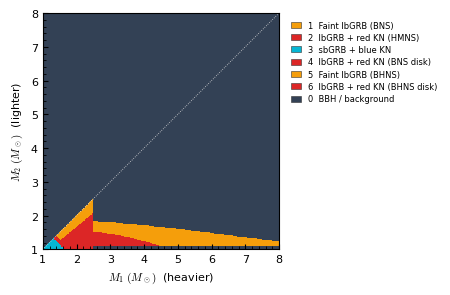

In [5]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from grb_classify import GRID_CLASS_LABELS
from grb_plot_style import C_SB_BLUE, C_LB_HMNS, C_LB_DISK, C_FAINT, C_NO_GRB

grid_axis = np.linspace(1.0, 8.0, 400)
m1g, m2g = np.meshgrid(grid_axis, grid_axis)
grid = classify_grid(m1g, m2g, ns_max=2.5, R_1p4_km=12.0)

# classify_grid is symmetric in (m1, m2), so keep only the m1 >= m2 half
# (the upper triangle is its mirror image) and drop label 0 (BBH, out of
# range, or below the NS floor).  Both masked regions show as the project
# background grey, so the populated BNS triangle and BHNS strip stand out.
grid_plot = np.ma.array(grid, mask=(grid == 0) | (m2g > m1g))

# Discrete palette keyed to grb_classify.GRID_CLASS_LABELS (1-6), reusing
# the locked grb_plot_style hexes.  The two lbGRB + red KN classes share
# the project red and the two faint classes share the project amber, so the
# BNS triangle and the BHNS strip are read apart by position and the legend
# rather than by hue.
grid_colors = [C_FAINT, C_LB_HMNS, C_SB_BLUE, C_LB_DISK, C_FAINT, C_LB_DISK]
cmap_grid = ListedColormap(grid_colors)
norm_grid = BoundaryNorm(np.arange(0.5, 7.5, 1.0), cmap_grid.N)

fig, ax = plt.subplots(figsize=(5.2, 3.0))
ax.set_facecolor(C_NO_GRB)  # BBH / unclassified background
ax.pcolormesh(m1g, m2g, grid_plot, cmap=cmap_grid, norm=norm_grid,
              shading="nearest", rasterized=True)
ax.plot([1, 8], [1, 8], color="0.85", lw=0.6, ls=":")  # m1 = m2 diagonal

ax.set_xlim(1, 8)
ax.set_ylim(1, 8)
ax.set_aspect("equal")
ax.set_xlabel(r"$M_1\ (M_\odot)$  (heavier)")
ax.set_ylabel(r"$M_2\ (M_\odot)$  (lighter)")

# Discrete legend: the labels are categorical, so a continuous 1-6 colorbar
# would misread as an ordinal scale.
handles = [Patch(facecolor=grid_colors[k - 1], edgecolor="0.2", lw=0.4,
                 label=f"{k}  {GRID_CLASS_LABELS[k]}")
           for k in sorted(GRID_CLASS_LABELS)]
handles.append(Patch(facecolor=C_NO_GRB, edgecolor="0.2", lw=0.4,
                     label="0  BBH / background"))
ax.legend(handles=handles, fontsize=6, loc="upper left",
          bbox_to_anchor=(1.02, 1.0), frameon=False,
          handlelength=1.2, labelspacing=0.4)
fig.tight_layout()
plt.show()

**Source.** `classify_grid` at [grb_classify.py L227](src/grb_classify.py#L227). Places both populations and all six classes on a single $(M_1, M_2)$ axis, the one view that ties the BNS and BHNS branches together. This is a coarse live preview; the publication mass-plane figures (Section 1) are weighted reflective-boundary KDEs with the boundary lines overlaid, embedded in the Mass-plane block below.

### Stage 3. Cross-checks against the literature anchors

Before any figure is trusted, the live constants are checked against the values they are supposed to carry, and the classifier outputs are checked for closure (the weighted class fractions must sum to one because every merging system lands in exactly one class). This mirrors the `tests/anchors` discipline of the project (every cited number is pinned to its paper-quoted value) and turns the walkthrough into a self-verifying document: if a constant drifts, the cell below raises instead of silently producing a wrong figure.

In [6]:
# Literature-anchor checks: every constant pinned to its paper-quoted value.
assert M_TOV == 2.2, "M_TOV must be 2.2 Msun (Raaijmakers+ 2021, arXiv:2105.06981)"
assert np.isclose(M_THRESH, 1.27 * M_TOV), (
    "M_THRESH must be 1.27 * M_TOV (Gottlieb+ 2023 fiducial, arXiv:2309.00038)"
)
assert (MDISK_SHORT, MDISK_LONG) == (0.01, 0.1), (
    "BHNS disk cuts must be 0.01 / 0.1 Msun (Gottlieb+ 2023 Fig. 6, arXiv:2309.00038)"
)
assert Q_THRESH_BNS == 1.2, "q_thresh must be 1.2 (Gottlieb+ 2023, arXiv:2309.00038)"

# Closure checks: each merging system lands in exactly one class, so the
# STROOPWAFEL-weighted class fractions must sum to one.
bns_total = sum(weighted_fractions(bns_cls, w).values())
bhns_total = sum(weighted_fractions(bhns_cls, bhns["weights"]).values())
assert np.isclose(bns_total, 1.0), f"BNS class fractions sum to {bns_total}, expected 1"
assert np.isclose(bhns_total, 1.0), f"BHNS class fractions sum to {bhns_total}, expected 1"

print("all literature-anchor and closure checks passed")
print(f"  BNS class fractions sum  = {bns_total:.6f}")
print(f"  BHNS class fractions sum = {bhns_total:.6f}")

all literature-anchor and closure checks passed
  BNS class fractions sum  = 1.000000
  BHNS class fractions sum = 1.000000


## Part B. Section-by-section walkthrough

Each entry lists what the section shows, the loader it uses, the key calls, the governing thresholds, and the saved figures. Section numbers and titles match the markdown headers in `grb_main.ipynb`. The figures below are the committed `plots/*.png` previews; the publication PDFs sit next to them.

### Mass plane (Sections 1, 2, 2b)

- Section 1, Mass Plane, BNS and BHNS. Renders the weighted reflective-boundary `gaussian_kde` of each population with the Gottlieb (2024) / Foucart (2018) boundary lines overlaid (`bns_boundary_lines`; the BHNS panel evaluates `foucart_disk_mass` for its disk-mass contours). There is no `classify_grid` underlay; that is the coarse Stage 2 preview above. Output: `plots/mass_plane_bns.{pdf,png}`, `plots/mass_plane_bhns.{pdf,png}`.
- Section 2, Component Mass Distributions by GRB Class. Weighted component-mass histograms split by the `classify_bns_2024` / `classify_bhns` masks. Output: `plots/mass_distributions_by_class.{pdf,png}`.
- Section 2b, Sensitivity to the NS-mass remap. Re-classifies under raw, flat (`uniform_mass_cdf`), and Alsing remaps via `remap_ns_masses_double_gaussian` to show how much of the demographics is set by the imposed mass function. Output: `plots/remap_sensitivity_bns.{pdf,png}`.

**Per-plot description.** Ingestion to figure, one row per saved plot.

| Figure | In | Transform | Assumes | Models | Citations |
|---|---|---|---|---|---|
| `mass_plane_bns` | `load_bns` A + merger cut + weights | remapped (m1, m2) -> m1 <-> m2 symmetrised reflective-boundary weighted `gaussian_kde` -> overlay `bns_boundary_lines` | weighted KDE, not `classify_grid`; reflective wall at M_TOV = 2.2; cumulative-fraction contour levels | population: COMPAS A; physics: Gottlieb 2024 boundaries, Silverman 1986 KDE | `grb_classify.bns_boundary_lines`, `scipy.stats.gaussian_kde`; Gottlieb et al. 2023 (arXiv:2309.00038) |
| `mass_plane_bhns` | `load_bhns` A + merger cut + weights | `remap_ns_marginal` -> reflective KDE in (M_BH, M_NS) -> `foucart_disk_mass` boundary contours | KDE only (classification enters at the rate stage); Foucart valid for chi in [-0.5, 0.9], Q in [1, 7] | population: COMPAS A; physics: Foucart 2018 disk, KF 2020 ejecta | `grb_physics.foucart_disk_mass`; Foucart et al. 2018 (arXiv:1807.00011), Kruger and Foucart 2020 (arXiv:2002.07728) |
| `mass_distributions_by_class` | `load_bns` / `load_bhns` A | remapped masses -> `classify_bns_2024` / `classify_bhns` -> `weighted_hist_pdf` of M1, M2, M_tot, q per class | abundance-normalised partial density dP/dx; area equals the class fraction | population: COMPAS A | `grb_plot_style.weighted_hist_pdf`, `classify_bns_2024` / `classify_bhns`; Gottlieb et al. 2023 (arXiv:2309.00038), 2025 (arXiv:2411.13657) |
| `remap_sensitivity_bns` | `load_bns` A | re-classify under raw masses, a flat `uniform_mass_cdf` remap, and the Alsing `remap_ns_masses_double_gaussian` | bounds how much of the demographics is imposed by the mass function rather than the population | population: COMPAS A; physics: Alsing 2018 vs flat prior | `grb_physics.uniform_mass_cdf` / `remap_ns_masses_double_gaussian`; Alsing, Silva and Berti 2018 (arXiv:1709.07889) |

_Why it matters:_ the mass plane shows the classification boundaries falling where the COMPAS population actually sits, so the class fractions are a property of the population, not of where the lines were drawn.

![BNS mass plane](plots/mass_plane_bns.png)

![BHNS mass plane](plots/mass_plane_bhns.png)

![Component mass distributions by GRB class](plots/mass_distributions_by_class.png)

![Sensitivity of BNS class fractions to the NS-mass remap](plots/remap_sensitivity_bns.png)

### Delay times (Sections 3, 3b)

- Section 3, Delay Time Distributions by GRB Class. Weighted PDFs of `delay_time` ( = `tform + tc`, Myr) per Gottlieb class. Output: `plots/delay_time_distributions.{pdf,png}`.
- Section 3b, split by formation channel. Uses `load_bns_with_channels` plus `classify_formation_channels` to break each class into Broekgaarden channels I to V. Output: `plots/delay_time_by_class_per_channel.{pdf,png}` and the BHNS variant `plots/delay_time_bhns_by_class_per_channel.{pdf,png}`.

**Per-plot description.** Ingestion to figure, one row per saved plot.

| Figure | In | Transform | Assumes | Models | Citations |
|---|---|---|---|---|---|
| `delay_time_distributions` | `load_bns` A | remapped masses -> `classify_bns_2024` -> `weighted_hist_pdf` of `delay_time` (tform + tc, Myr) per class | weighted PDF; intrinsic shape, no rate weighting | population: COMPAS A | `weighted_hist_pdf`, `classify_bns_2024`; Gottlieb et al. 2023 (arXiv:2309.00038) |
| `delay_time_by_class_per_channel` | `load_bns_with_channels` A | `classify_formation_channels` (I-V) intersect class masks -> per-channel weighted delay PDF normalised to the per-class total | channel curves sum bin by bin to the per-class total | population: COMPAS A; channels Broekgaarden I-V | `classify_formation_channels`; Broekgaarden et al. 2021 (arXiv:2103.02608), 2022 (arXiv:2112.05763) |
| `delay_time_bhns_by_class_per_channel` | `load_bhns_with_channels` A | same chain on the BHNS classes (channels I, II populated) | misalignment is a flat 0.5 rate scalar and leaves the shape unchanged | population: COMPAS A | `classify_formation_channels`, `classify_bhns`; Broekgaarden et al. 2021 / 2022 |

_Why it matters:_ the delay-time distribution per class sets which redshifts each GRB class can reach, the input the cosmic-rate integration convolves with the star-formation history.

![Delay-time distributions by GRB class](plots/delay_time_distributions.png)

![Delay time per GRB class, split by formation channel (BNS)](plots/delay_time_by_class_per_channel.png)

![Delay time per GRB class, split by formation channel (BHNS)](plots/delay_time_bhns_by_class_per_channel.png)

### Formation efficiency (Sections 5, 5b)

- Section 5, Metallicity Dependence of GRB Formation Efficiency. `formation_efficiency` per class on a log-Z axis (truncated at the physical maximum). Output: `plots/metallicity_dependence.{pdf,png}`.
- Section 5b, per class split by channel. Intensive per-channel efficiency. Output: `plots/metallicity_by_class_per_channel.{pdf,png}` and the BHNS variant.

**Per-plot description.** Ingestion to figure, one row per saved plot.

| Figure | In | Transform | Assumes | Models | Citations |
|---|---|---|---|---|---|
| `metallicity_dependence` | `load_bns` / `load_bhns` A | remapped masses -> class masks -> `formation_efficiency` eta(Z) on 15 equal-count log-Z bins; `metallicity_prior_mass_fraction` for the prior | mergers per Msun formed; bins shown where raw N >= 50, Kish n_eff >= 10, Z <= Z_sun | population: COMPAS A; STROOPWAFEL prior | `grb_rates.formation_efficiency` / `metallicity_prior_mass_fraction`; Broekgaarden et al. 2019 (arXiv:1905.00910) |
| `metallicity_by_class_per_channel` (and BHNS variant) | `load_*_with_channels` A | `classify_formation_channels` intersect class -> intensive per-channel eta(Z) | per-channel sum equals the per-class total bin by bin | population: COMPAS A; channels I-V | `formation_efficiency`, `classify_formation_channels`; Broekgaarden et al. 2021 / 2022 |

_Why it matters:_ the metallicity dependence shows which environments preferentially make each class, the lever that turns a star-formation history into a class-resolved rate.

![Metallicity dependence of GRB formation efficiency](plots/metallicity_dependence.png)

![Metallicity dependence per GRB class, split by formation channel (BNS)](plots/metallicity_by_class_per_channel.png)

![Metallicity dependence per GRB class, split by formation channel (BHNS)](plots/metallicity_bhns_by_class_per_channel.png)

### Cosmic rates and formation channels (Sections 4, 4b, 4c, 6, 6a, 6b, 7, 7b, 10)

Rates live in [src/grb_rates.py](src/grb_rates.py), a chunked accumulator around the COMPAS `FastCosmicIntegration` routines. The metallicity-specific star-formation rate density (MSSFR) is the Levina et al. (2026, arXiv:2601.20202) IllustrisTNG TNG100-1 skew-log-normal fit, with the Madau and Dickinson (2014, arXiv:1403.0007) star-formation-rate functional form; the cosmology is fixed to Planck 2015 (Planck Collaboration 2016, arXiv:1502.01589) to match the COMPAS code constants.

- Section 4, Cosmic Integration setup. Builds the MSSFR grid and calibrates the per-population `MEAN_MASS_EVOLVED` with `calibrate_mean_mass_evolved`, which back-derives the normalization from the upstream Neijssel et al. (2019, arXiv:1906.08136) `w_000` anchor using `smooth_sigma=0` (the unsmoothed convolution).
- Section 4b, TNG-resolution sweep. Three `compute_merger_rate` runs (TNG50/100/300) on the BNS A sample, shaded as a systematic band. Output: `plots/rate_bns_tng_sweep.{pdf,png}`.
- Section 4c, absolute-rate cross-check. `detected_rate` summed over the detectable redshift slice gives predicted LVK detection counts.
- Section 6, BNS R(z) per class. `compute_merger_rate` per `classify_bns_2024` mask, plus a detected-vs-intrinsic panel. Output: `plots/rate_bns_by_class.{pdf,png}`.
- Section 6a, sensitivity to the star-formation history. Output: `plots/rate_bns_mssfr_crosscheck.{pdf,png}`.
- Section 6b, BNS R(z) per class split by channel (channel x class product). Output: `plots/rate_bns_by_class_per_channel.{pdf,png}`.
- Section 7, BHNS R(z) with BH-spin sensitivity. `marginalize_bh_spin` over the spin grid at `A_BH_FID`, then `apply_bhns_misalignment` (population-level factor 0.5, motivated by the spin-orbit tilt distributions of Fragos et al. 2010, arXiv:1001.1107 and the disk-mass suppression in the Kawaguchi et al. 2015, arXiv:1506.05473 numerical-relativity simulations). Output: `plots/rate_bhns_spin_sensitivity.{pdf,png}`.
- Section 7b, BHNS R(z) per class split by channel, misalignment-corrected per cell. Output: `plots/rate_bhns_by_class_per_channel.{pdf,png}`.
- Section 10, jet breakout and the observable-rate ladder. The intended chain is `breakout_fraction_bns_eos` (EOS-marginalized over the Read et al. 2009, arXiv:0812.2163 radii; remnant-conditioned), following the BNS jet-breakout criterion of Pais et al. (2024, arXiv:2407.19002), then `apply_bns_jet_breakout` then `beamed_rate`, compared against `OBSERVED_SGRB_RATES` (including Wanderman and Piran 2015, arXiv:1405.5878). Output: `plots/fig10_bns_jet_breakout.{pdf,png}`.

Two interpretation rules apply throughout the rate sections. Rates are intrinsic by default; compare against observed sGRB rates only after `beamed_rate`, and against the LVK GWTC-5.0 intrinsic GW rates (Abac et al. 2026, arXiv:2605.27226) without any beaming or misalignment factor. Quote R(z=0) only from unsmoothed arrays (`smooth_sigma=0`), re-smoothing a display copy at plot time.

**Per-plot description.** Ingestion to figure, one row per saved plot. Sections 4 (MSSFR setup and calibration) and 4c (predicted LVK detection counts via `detected_rate`) produce no standalone saved figure; they feed the rows below.

| Figure | In | Transform | Assumes | Models | Citations |
|---|---|---|---|---|---|
| `rate_bns_by_class` | `load_bns` A | remapped -> `classify_bns_2024` -> per-class `compute_merger_rate`; companion panel via `detected_rate` | intrinsic by default; class curves sum to the total; detected panel rho >= 8 out to z = 1 | population: COMPAS A; physics: Levina 2026 TNG100 MSSFR, Madau and Dickinson 2014 SFR, Planck 2015 | `compute_merger_rate`, `detected_rate`; Gottlieb et al. 2023 (arXiv:2309.00038), Levina et al. 2026 (arXiv:2601.20202) |
| `rate_bns_by_class_per_channel` | `load_bns_with_channels` A | `classify_formation_channels` intersect class -> per-cell `compute_merger_rate` | channel x class product; smooth_sigma = 0 keeps the curves additive | population: COMPAS A; channels I-V | `compute_merger_rate`, `classify_formation_channels`; Broekgaarden et al. 2021 / 2022 |
| `rate_bns_mssfr_crosscheck` | `load_bns` A | re-run `compute_merger_rate` per class under the Neijssel 2019 MSSFR against the fiducial Levina 2026 | brackets the star-formation-history systematic | population: COMPAS A; physics: Neijssel 2019 vs Levina 2026 MSSFR | `compute_merger_rate`; Neijssel et al. 2019 (arXiv:1906.08136), Levina et al. 2026 (arXiv:2601.20202) |
| `rate_bns_tng_sweep` | `load_bns` A | `calibrate_mean_mass_evolved` -> `compute_merger_rate` x3 over `LEVINA26_TNG_VARIANTS` (TNG50 / 100 / 300) | intrinsic; band is the simulation-resolution systematic; smooth_sigma = 0 anchor | population: COMPAS A; physics: Levina 2026 TNG MSSFR | `compute_merger_rate`, `LEVINA26_TNG_VARIANTS`; Levina et al. 2026 (arXiv:2601.20202) |
| `rate_bhns_spin_sensitivity` | `load_bhns` A | `remap_ns_marginal` -> `classify_bhns` -> per-spin `apply_bhns_misalignment(compute_merger_rate)` -> `marginalize_bh_spin` over the spin grid | intrinsic; misalignment 0.5 applied at the rate stage and commutes with the spin marginalisation | population: COMPAS A; physics: Foucart 2018, BH-spin priors | `marginalize_bh_spin`, `apply_bhns_misalignment`; Foucart et al. 2018 (arXiv:1807.00011), Fragos et al. 2010 (arXiv:1001.1107), Kawaguchi et al. 2015 (arXiv:1506.05473) |
| `rate_bhns_by_class_per_channel` | `load_bhns_with_channels` A | `classify_formation_channels` intersect class -> `apply_bhns_misalignment(compute_merger_rate)` per cell at `A_BH_FID` | misalignment applied per cell | population: COMPAS A; channels I, II | `compute_merger_rate`, `apply_bhns_misalignment`; Broekgaarden et al. 2021 / 2022 |
| `fig10_bns_jet_breakout` | `load_bns` A | remapped -> `classify_bns_2024` -> `breakout_fraction_bns_eos` -> `apply_bns_jet_breakout` -> `beamed_rate`, compared to the Colombo et al. 2022 local sGRB rate | EOS-marginalised over `EOS_MODELS`, remnant-conditioned; the corrected rate is no longer an upper bound; beaming applied after breakout | population: COMPAS A; physics: Pais 2024 breakout, Read 2009 radii | `breakout_fraction_bns_eos`, `apply_bns_jet_breakout`, `beamed_rate`; Pais et al. 2024 (arXiv:2407.19002), Read et al. 2009 (arXiv:0812.2163), Colombo et al. 2022 (arXiv:2204.07592) |

_Why it matters:_ these per-class $\mathcal{R}(z)$ curves are the headline numbers the paper compares against the observed sGRB and LVK rates, after the beaming and breakout corrections noted below.

![BNS merger rate per GRB class](plots/rate_bns_by_class.png)

![BNS merger rate per GRB class, split by formation channel](plots/rate_bns_by_class_per_channel.png)

![BNS rate sensitivity to the star-formation history](plots/rate_bns_mssfr_crosscheck.png)

![BNS rate TNG-resolution sweep](plots/rate_bns_tng_sweep.png)

![BHNS merger rate with BH-spin sensitivity](plots/rate_bhns_spin_sensitivity.png)

![BHNS merger rate per GRB class, split by formation channel](plots/rate_bhns_by_class_per_channel.png)

![BNS jet breakout efficiency and the observable-rate ladder](plots/fig10_bns_jet_breakout.png)

### Offset plots (Sections 8, 8b)

Host-galaxy offsets live in [src/grb_offsets.py](src/grb_offsets.py). Post-SN systemic velocity (`v_sys` from `load_*_with_kicks`) is integrated through a Hernquist (1990, ApJ 356, 359) potential to a projected galactocentric offset at merger time.

- Section 8, Physical Host-Galaxy Offset Distributions. `compute_offsets_mixed_hosts` over the `HOST_MODELS` mixture (SF disk / SF massive / elliptical, anchored on the sGRB host sample of Fong and Berger 2013, arXiv:1307.0819), `weighted_offset_cdf` for the CDF, and `weighted_ks_2samp` for the two-sample comparison against `OBSERVED_SGRB_OFFSETS_KPC` (never the unweighted scipy KS on STROOPWAFEL samples). Output: `plots/projected_offsets.{pdf,png}`.
- Section 8b, across supernova-kick variations. Reloads Models A, M, N (plus O for BHNS) via `load_*_with_kicks` and recomputes offsets per kick model. Output: `plots/projected_offsets_kick_models.{pdf,png}`.

**Per-plot description.** Ingestion to figure, one row per saved plot.

| Figure | In | Transform | Assumes | Models | Citations |
|---|---|---|---|---|---|
| `projected_offsets` | `load_bns_with_kicks` A (v_sys via `_match_sn_to_dco`) | `compute_offsets_mixed_hosts` over `HOST_MODELS` -> `weighted_offset_cdf` -> `weighted_ks_2samp` against `OBSERVED_SGRB_OFFSETS_KPC` | Hernquist potential; host mixture (SF disk / SF massive / elliptical); weighted KS, never the unweighted scipy KS | population: COMPAS A; physics: Hernquist 1990, Fong and Berger 2013 hosts | `grb_offsets.compute_offsets_mixed_hosts` / `weighted_offset_cdf` / `weighted_ks_2samp`; Hernquist 1990, Fong and Berger 2013 (arXiv:1307.0819) |
| `projected_offsets_kick_models` | `load_*_with_kicks` for A, M, N (plus O for BHNS) | per-kick-model `compute_offsets_mixed_hosts` recompute | the offset shift isolates the SN-kick prescription | population: COMPAS A / M / N (+O); physics: Hernquist 1990 | `compute_offsets_mixed_hosts`; Broekgaarden et al. 2021 / 2022, Hernquist 1990 |

_Why it matters:_ the projected offset distribution is the most direct observable test of the kinematic model, checking whether the predicted host-galaxy offsets reproduce the observed sGRB sample (Fong and Berger 2013).

![Projected host-galaxy offset distributions](plots/projected_offsets.png)

![Projected offsets across supernova-kick variations](plots/projected_offsets_kick_models.png)

### All 20 models (Section 11)

The 20-model grid is the full set of population-synthesis variations from Broekgaarden et al. (2021, arXiv:2103.02608) and the paper-II companion (Broekgaarden et al. 2022, arXiv:2112.05763). Model suffixes use the paper-II letter convention; the paper-I to paper-II crosswalk (A=A, F=H, G=I, J=M, K=N) is printed in Section 11.0.

- Section 11.0, setup and metadata validation. Validates the 40 HDF5 files (BNS and BHNS for each suffix in `ALL_MODEL_SUFFIXES`).
- Section 11.0b, streaming grid scan. Loops once over the 20 models (the only permitted Python loop over models), each iteration loading one model, applying the per-model remap (seeds `42 + i` / `43 + i`), calibrating `MEAN_MASS_EVOLVED` per population, classifying, and integrating the rate. It pulls `ns_max` from the embedded metadata so the cap matches each run. Results cache to `plots/grid_scan_results.npz` and `plots/grid_scan_summary.csv`; the scan is cache-aware, so delete the npz to force a re-scan.
- Section 11.1 / 11.1b, GRB class versus formation-channel composition across the grid (BNS and BHNS), via `channel_class_crosstab`. Section 11.1 also compares R(z=0) against the LVK GWTC-5.0 intrinsic rates (Abac et al. 2026, arXiv:2605.27226).
- Section 11.6, dense-matter EOS x model class matrix over `EOS_MODELS` (M_crit from Bauswein et al. 2013, arXiv:1302.6530; R_1.4 from Read et al. 2009, arXiv:0812.2163). Output: `plots/eos_x_model_matrix_20models.{pdf,png}`.

The class-fraction, channel-fraction, and composition figures viewed alongside this scan are `plots/class_fractions_20models`, `plots/channel_fractions_20models`, `plots/composition_bns_20models`, and `plots/composition_bhns_20models`.

**Per-plot description.** Ingestion to figure, one row per saved plot. All rows share the Section 11.0b streaming scan over `ALL_MODEL_SUFFIXES` (one model in memory at a time, cache-aware via `plots/grid_scan_results.npz`).

| Figure | In | Transform | Assumes | Models | Citations |
|---|---|---|---|---|---|
| `class_fractions_20models` | streaming `load_*_with_channels` over `ALL_MODEL_SUFFIXES` | per-model remap (seeds 42+i / 43+i) -> `classify_bns_2024` / `classify_bhns` -> weighted class fractions; ns_max from the embedded HDF5 attribute | per-model `MEAN_MASS_EVOLVED` is mandatory; ns_max cannot drift from the run | population: full 20-model grid | `classify_grid`, `calibrate_mean_mass_evolved`; Broekgaarden et al. 2021 (arXiv:2103.02608), 2022 (arXiv:2112.05763) |
| `channel_fractions_20models` | same scan | `classify_formation_channels` -> weighted channel fractions per model | channels I-V | population: 20-model grid | `classify_formation_channels`; Broekgaarden et al. 2021 / 2022 |
| `composition_bns_20models` | same scan | `channel_class_crosstab` -> P(class given channel) per model | contingency normalised within channel | population: 20-model grid | `channel_class_crosstab`; Broekgaarden et al. 2021 / 2022, Gottlieb et al. 2023 / 2025 |
| `composition_bhns_20models` | same scan | same `channel_class_crosstab` on the BHNS classes | channels I, II | population: 20-model grid | `channel_class_crosstab`, `classify_bhns`; Broekgaarden et al. 2021 / 2022 |
| `eos_x_model_matrix_20models` | scan plus `EOS_MODELS` | per (model, EOS) recompute the four-class BNS fractions with m_tov and k = M_crit / M_TOV from `ns_radius_from_eos` | EOS moves both thresholds together; sbGRB boundary is hmns_factor * M_TOV | population: 20-model grid; physics: APR4 / SFHo / LS220 / DD2 | `EOS_MODELS`, `ns_radius_from_eos`; Bauswein et al. 2013 (arXiv:1302.6530), Read et al. 2009 (arXiv:0812.2163) |

_Why it matters:_ the 20-model grid is the robustness statement, showing how far the class fractions and rates move across the full range of population-synthesis assumptions.

![GRB class fractions across the 20-model grid](plots/class_fractions_20models.png)

![Formation-channel fractions across the 20-model grid](plots/channel_fractions_20models.png)

![BNS class versus formation-channel composition](plots/composition_bns_20models.png)

![BHNS class versus formation-channel composition](plots/composition_bhns_20models.png)

![EOS x model class matrix](plots/eos_x_model_matrix_20models.png)

### Parameter exploration (Sections 9, 11.2, 11.3, 11.4, 11.5, 11.7)

- Section 9, Population-Synthesis Variations: Models A, H, I, M, N (paper-II letters; the paper-I core five A, F, G, J, K map to A, H, I, M, N, see the Section 11.0 crosswalk). Per-model remap and calibration, then 9.1 BNS class fractions vs M_NS,max (Models M, A, N; `plots/class_fractions_ns_max.{pdf,png}`) and 9.2 BNS delay-time CDF by model (`plots/delay_time_cdf_by_model.{pdf,png}`).
- Section 11.2, the full alpha_CE sequence (common-envelope efficiency). Output: `plots/class_fractions_alpha_ce_5pt.{pdf,png}`.
- Section 11.3, mass-transfer efficiency beta sweep. Output: `plots/class_fractions_beta_sweep.{pdf,png}`.
- Section 11.4, supernova remnant engine, delayed vs rapid (both prescriptions from Fryer et al. 2012, arXiv:1110.1726). Output: `plots/class_fractions_sn_engine.{pdf,png}`.
- Section 11.5, channel x class contingency for case BB and CE survival. Output: `plots/channel_class_casebb_ce.{pdf,png}`.
- Section 11.7, sensitivity of the class ordering to the HMNS split factor, by re-running `classify_bns_2024` across a range of `hmns_factor`.

Section 12 (GRB Engine Classification Scheme) renders the Figure 1 decision tree itself via `classify_grid`; output `plots/fig15_classification_scheme.pdf`.

**Per-plot description.** Ingestion to figure, one row per saved plot.

| Figure | In | Transform | Assumes | Models | Citations |
|---|---|---|---|---|---|
| `class_fractions_ns_max` | `load_bns` M, A, N | per-model remap plus `calibrate_mean_mass_evolved` -> `classify_bns_2024` -> weighted fractions vs M_NS,max | ns_max per run (2.0 / 2.5 / 3.0); per-model calibration is mandatory | population: COMPAS M / A / N | `classify_bns_2024`, `calibrate_mean_mass_evolved`; Broekgaarden et al. 2021 / 2022 |
| `class_fractions_alpha_ce_5pt` | grid-scan subset | `classify_bns_2024` on remapped masses across the alpha_CE sequence | isolates the common-envelope efficiency | population: alpha_CE variations | `classify_bns_2024`; Broekgaarden et al. 2021 / 2022 |
| `class_fractions_beta_sweep` | grid-scan subset | same chain, across the mass-transfer efficiency beta | isolates beta | population: beta variations | `classify_bns_2024`; Broekgaarden et al. 2021 / 2022 |
| `class_fractions_sn_engine` | grid-scan subset | same chain, delayed vs rapid remnant engine | both engines are Fryer et al. 2012 prescriptions | population: engine variations | `classify_bns_2024`; Fryer et al. 2012 (arXiv:1110.1726) |
| `channel_class_casebb_ce` | `load_bns_with_channels` | `channel_class_crosstab` for the case-BB and CE-survival contingency | channel x class normalised within channel | population: COMPAS A | `channel_class_crosstab`; Broekgaarden et al. 2021 / 2022 |
| `fig15_classification_scheme` | synthetic (M1, M2) grid | `classify_grid` -> labelled decision regions | the Figure 1 tree itself; a coarse grid, not a population | physics: all thresholds in `grb_physics` | `classify_grid`, `GRID_CLASS_LABELS`; Gottlieb et al. 2023 (arXiv:2309.00038), 2025 (arXiv:2411.13657) |

_Why it matters:_ isolating one physics knob at a time (alpha_CE, beta, SN engine, M_NS,max) shows which assumption each class fraction is actually sensitive to.

![BNS class fractions vs maximum NS mass](plots/class_fractions_ns_max.png)

![Class fractions across the full alpha_CE sequence](plots/class_fractions_alpha_ce_5pt.png)

![Class fractions across the mass-transfer efficiency sweep](plots/class_fractions_beta_sweep.png)

![Class fractions for the delayed vs rapid supernova engine](plots/class_fractions_sn_engine.png)

![Channel x class contingency for case BB and CE survival](plots/channel_class_casebb_ce.png)

![GRB engine classification scheme (Figure 1 decision tree)](plots/fig15_classification_scheme.png)

## Part C. Reference

### Module responsibilities

| Module | Responsibility in this pipeline |
|---|---|
| [src/grb_io.py](src/grb_io.py) | COMPAS HDF5 loaders, merger cut, weights, BH/NS identity, metallicity grid, weighted subsampling, kick/velocity join |
| [src/grb_physics.py](src/grb_physics.py) | NS-mass remap, Foucart 2018 remnant mass, KF 2020 disk and dynamical ejecta, EOS models, thresholds, Gottlieb 2025 and Pais 2024 helpers |
| [src/grb_classify.py](src/grb_classify.py) | BNS 4-class, BHNS 3-class, unified mass-plane grid, Broekgaarden formation channels, channel x class crosstab, observed-merger classifier |
| [src/grb_rates.py](src/grb_rates.py) | Cosmic-integration rates, calibration, formation efficiency, BH-spin and misalignment, beaming, jet breakout, observed and LVK reference rates |
| [src/grb_offsets.py](src/grb_offsets.py) | Hernquist orbit integration, projected offset CDFs, host models, weighted KS test |
| [src/grb_plot_style.py](src/grb_plot_style.py) | Project palette and ApJ rcParams; per-model and per-channel colour tables |

### Interpretation gotchas

- Weights are mandatory. Any unweighted count or mean over the COMPAS sample is biased.
- The NS-mass remap is global. Downstream code uses remapped masses; do not reload raw masses without reapplying it.
- Rates are intrinsic by default. Apply `beamed_rate` before comparing to observed sGRB rates; apply neither beaming nor misalignment when comparing to LVK GW rates.
- Disk-mass GRB rates are 100 percent jet-launching upper bounds until a Pais et al. (2024) breakout factor is applied via `apply_bns_jet_breakout`.
- `ns_max` must match the COMPAS run. The Section 11 scan reads it from the embedded HDF5 attribute so it cannot drift; a hardcoded literal in new code is a regression.
- Quote R(z=0) only from unsmoothed (`smooth_sigma=0`) arrays.

### Reproducibility

Every figure regenerates from a notebook cell. Random seeds are fixed. Re-execute `comparison.ipynb` (fast) and `grb_main.ipynb` (slow) with the `grb-env` kernel, for example `jupyter nbconvert --to notebook --execute --inplace grb_main.ipynb`. Section 11 is cache-aware: it skips the 40-file rescan when `plots/grid_scan_results.npz` already holds the expected arrays, so delete the npz to force a full re-scan. Figure styling comes from the canonical ApJ rcParams block (`grb_plot_style.apply_apj_rcparams`).

### References

Citations follow the project bibliography ([overleaf-paper/grb_paper.bib](overleaf-paper/grb_paper.bib)). arXiv identifiers are given where one exists.

- Abac et al. 2026, GWTC-5.0: Population Properties of Merging Compact Binaries, arXiv:2605.27226.
- Alsing, Silva and Berti 2018, MNRAS 478, 1377, arXiv:1709.07889.
- Bardeen, Press and Teukolsky 1972, ApJ 178, 347.
- Bauswein, Baumgarte and Janka 2013, Phys. Rev. Lett. 111, 131101, arXiv:1302.6530.
- Bauswein et al. 2020, Phys. Rev. Lett. 125, 141103, arXiv:2004.00846.
- Broekgaarden et al. 2019, STROOPWAFEL, MNRAS 490, 5228, arXiv:1905.00910.
- Broekgaarden et al. 2021, MNRAS 508, 5028, arXiv:2103.02608 (paper I).
- Broekgaarden et al. 2022, MNRAS 516, 5972, arXiv:2112.05763 (paper II).
- Colombo et al. 2022, ApJ 937, 79, arXiv:2204.07592.
- Fong and Berger 2013, ApJ 776, 18, arXiv:1307.0819.
- Foucart, Hinderer and Nissanke 2018, Phys. Rev. D 98, 081501, arXiv:1807.00011.
- Fragos et al. 2010, ApJ 719, L79, arXiv:1001.1107.
- Fryer et al. 2012, ApJ 749, 91, arXiv:1110.1726.
- Gottlieb et al. 2023, A Unified Picture of Short and Long GRBs from Compact Binary Mergers, arXiv:2309.00038.
- Gottlieb et al. 2025, A Unified Model of Kilonovae and GRBs, arXiv:2411.13657 (ApJ 984, 77).
- Hernquist 1990, ApJ 356, 359.
- Kruger and Foucart 2020, Phys. Rev. D 101, 103002, arXiv:2002.07728.
- Kawaguchi et al. 2015, Phys. Rev. D 92, 024014, arXiv:1506.05473.
- Levina et al. 2026, arXiv:2601.20202.
- Madau and Dickinson 2014, ARA&A 52, 415, arXiv:1403.0007.
- Mandel and Muller 2020, MNRAS 499, 3214, arXiv:2006.08360.
- Margalit and Metzger 2017, ApJL 850, L19, arXiv:1710.05938.
- Neijssel et al. 2019, MNRAS 490, 3740, arXiv:1906.08136.
- Pais et al. 2024, arXiv:2407.19002.
- Planck Collaboration 2016 (Planck 2015 results), A&A 594, A13, arXiv:1502.01589.
- Raaijmakers et al. 2021, ApJL 918, L29, arXiv:2105.06981.
- Read et al. 2009, Phys. Rev. D 79, 124032, arXiv:0812.2163.
- Wanderman and Piran 2015, MNRAS 448, 3026, arXiv:1405.5878.